# AirFly Insights -- Data Visualization and Analysis of Airline Operations

This notebook covers the complete Milestone 1: Data Foundation and Cleaning.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set(style='whitegrid')

## 1. Load Raw Dataset

In [6]:
df = pd.read_csv('../data/flights.csv', low_memory=False)
print(df.shape)
df.dtypes

(5819079, 31)


YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
TAIL_NUMBER             object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE                 int64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON     object
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

## 2. Check Missing Values (Before Cleaning)

In [7]:
print(df.isnull().sum())

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64


## 3. Select Required Features

In [8]:
required_features = [
    # Time & Flight Info
    'YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',

    # Route Info
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE',

    # Time Columns
    'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
    'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',

    # Delay Columns
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
    'AIR_SYSTEM_DELAY', 'WEATHER_DELAY',
    'AIRLINE_DELAY', 'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY',

    # Cancellation & Diversion
    'CANCELLED', 'CANCELLATION_REASON', 'DIVERTED',

    # Flight Duration
    'AIR_TIME', 'ELAPSED_TIME', 'TAXI_IN', 'TAXI_OUT'
]
flights = df[required_features]
print(flights.columns)
print(flights.shape)

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'SCHEDULED_ARRIVAL',
       'ARRIVAL_TIME', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY',
       'WEATHER_DELAY', 'AIRLINE_DELAY', 'SECURITY_DELAY',
       'LATE_AIRCRAFT_DELAY', 'CANCELLED', 'CANCELLATION_REASON', 'DIVERTED',
       'AIR_TIME', 'ELAPSED_TIME', 'TAXI_IN', 'TAXI_OUT'],
      dtype='object')
(5819079, 27)


**Column meanings:**

    YEAR   -->  Year in which flight operated
    MONTH  -->  Month of flight (1-12)
    DAY    -->  Day of the month
    DAY_OF_WEEK  -->  Day number of week (1=Mon, 7=Sun)
    DATE   -->  Complete flight date
    AIRLINE --> IATA airline code
    FLIGHT_NUMBER --> Unique flight identifier
    ORIGIN_AIRPORT --> Starting airport
    DESTINATION_AIRPORT --> Destination airport
    DISTANCE --> Distance between airports (miles)
    SCHEDULED_DEPARTURE --> Planned departure time (HHMM)
    DEPARTURE_TIME --> Actual departure time
    SCHEDULED_ARRIVAL --> Planned arrival time
    ARRIVAL_TIME --> Actual arrival time
    DEPARTURE_DELAY --> Delay at departure (minutes)
    ARRIVAL_DELAY --> Delay at arrival (minutes)
    AIR_SYSTEM_DELAY --> Delay cause: NAS
    WEATHER_DELAY --> Delay cause: Weather
    AIRLINE_DELAY --> Delay cause: Carrier
    SECURITY_DELAY --> Delay cause: Security
    LATE_AIRCRAFT_DELAY --> Delay cause: Previous flight arrival
    CANCELLED --> Binary (1=Cancelled, 0=No)
    CANCELLATION_REASON --> A/B/C/D or Not Cancelled
    DIVERTED --> Binary (1=Diverted, 0=No)
    AIR_TIME --> Time in the air (minutes)
    ELAPSED_TIME --> Total flight time
    TAXI_IN --> Time from landing to gate
    TAXI_OUT --> Time from gate to takeoff

## 4. Handle Missing Values

### Delay Columns
Missing values in delay-related columns were replaced with zero because missing delay values indicate either no delay or cancelled flights.

Columns cleaned:
  * Departure Delay
  * Arrival Delay
  * Weather Delay
  * Airline Delay
  * Security Delay
  * Air System Delay
  * Late Aircraft Delay

In [9]:
delay_columns = [
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
    'AIR_SYSTEM_DELAY', 'WEATHER_DELAY',
    'AIRLINE_DELAY', 'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY'
]

flights = flights.copy()
flights.loc[:, delay_columns] = flights.loc[:, delay_columns].fillna(0)

### Cancellation Reason
* Cancellation Reason : Missing values in cancellation reason were replaced with "Not Cancelled" to clearly differentiate cancelled and non-cancelled flights.

**Cancellation Reason Codes:**

| Code | Meaning | Description |
|------|---------|-------------|
| **A** | **Airline/Carrier** | Cancellation due to issues within the airline's control (e.g., maintenance, crew problems, aircraft shortage) |
| **B** | **Weather** | Cancellation due to weather conditions (e.g., storms, fog, snow, hurricanes) |
| **C** | **National Air System (NAS)** | Cancellation due to air traffic control, airport operations, or other National Aviation System issues |
| **D** | **Security** | Cancellation due to security reasons (e.g., security breaches, threats) |
| **Not Cancelled** | **N/A** | The flight was not cancelled (this is what we filled in for missing values) |

In [10]:
flights['CANCELLATION_REASON'] = flights['CANCELLATION_REASON'].fillna('Not Cancelled')

* Completely blank rows were removed from the dataset.
* This ensured elimination of invalid records.

### Flight Duration Columns

Missing values in duration-related columns were filled using median values to avoid skewness caused by extreme flight durations.

Columns cleaned:
  * Air Time
  * Elapsed Time
  * Taxi In
  * Taxi Out

In [11]:
time_columns = ['AIR_TIME', 'ELAPSED_TIME', 'TAXI_IN', 'TAXI_OUT']

for col in time_columns:
    median_val = flights[col].median()
    count = flights[col].isnull().sum()
    flights[col] = flights[col].fillna(median_val)
    print(f"{col} -> Total rows filled: {count}")

AIR_TIME -> Total rows filled: 105071
ELAPSED_TIME -> Total rows filled: 105071
TAXI_IN -> Total rows filled: 92513
TAXI_OUT -> Total rows filled: 89047


# Fill DEPARTURE_TIME and ARRIVAL_TIME with 0 for cancelled flights
flights['DEPARTURE_TIME'] = flights['DEPARTURE_TIME'].fillna(0)
flights['ARRIVAL_TIME'] = flights['ARRIVAL_TIME'].fillna(0)
print(f"DEPARTURE_TIME filled with 0")
print(f"ARRIVAL_TIME filled with 0")

## 5. Post-Cleaning Verification

In [12]:
missing_values = flights.isnull().sum()
missing_values = missing_values[missing_values > 0]
print(missing_values)
print("\n")
datatype_count = flights.dtypes.value_counts()
for dtype, count in datatype_count.items():
    print(f"{dtype} -> {count} columns")
print("\n")
print("After Cleaning the Shape of the Dataset: ", flights.shape)

DEPARTURE_TIME    86153
ARRIVAL_TIME      92513
dtype: int64


float64 -> 13 columns
int64 -> 10 columns
object -> 4 columns


After Cleaning the Shape of the Dataset:  (5819079, 27)


## 6. Check Duplicates

In [13]:
duplicate_count = flights.duplicated().sum()
print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 0


## 7. Feature Engineering

In [14]:
# Create DATE column
flights['DATE'] = pd.to_datetime(flights[['YEAR', 'MONTH', 'DAY']])

# Create HOUR from SCHEDULED_DEPARTURE
flights['HOUR'] = (flights['SCHEDULED_DEPARTURE'] // 100).astype(int)
flights['HOUR'] = flights['HOUR'].clip(0, 23)

# Create ROUTE
flights['ROUTE'] = flights['ORIGIN_AIRPORT'].astype(str) + '-' + flights['DESTINATION_AIRPORT'].astype(str)

print(flights.shape)
flights.head()

(5819079, 30)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_DEPARTURE,...,CANCELLED,CANCELLATION_REASON,DIVERTED,AIR_TIME,ELAPSED_TIME,TAXI_IN,TAXI_OUT,DATE,HOUR,ROUTE
0,2015,1,1,4,AS,98,ANC,SEA,1448,5,...,0,Not Cancelled,0,169.0,194.0,4.0,21.0,2015-01-01,0,ANC-SEA
1,2015,1,1,4,AA,2336,LAX,PBI,2330,10,...,0,Not Cancelled,0,263.0,279.0,4.0,12.0,2015-01-01,0,LAX-PBI
2,2015,1,1,4,US,840,SFO,CLT,2296,20,...,0,Not Cancelled,0,266.0,293.0,11.0,16.0,2015-01-01,0,SFO-CLT
3,2015,1,1,4,AA,258,LAX,MIA,2342,20,...,0,Not Cancelled,0,258.0,281.0,8.0,15.0,2015-01-01,0,LAX-MIA
4,2015,1,1,4,AS,135,SEA,ANC,1448,25,...,0,Not Cancelled,0,199.0,215.0,5.0,11.0,2015-01-01,0,SEA-ANC


## Final Dataset Summary

After preprocessing and feature engineering, the dataset was transformed into a structured and analysis-ready format.

**Final Dataset Characteristics:**

**Total Records:** 5,819,079

**Total Columns:** 28 + engineered features

**Dataset is optimized for visualization and trend analysis.**

---
# Milestone 2: Visual Exploration and Delay Trends

This section covers:
* **Univariate Analysis** – Distribution of individual variables
* **Bivariate Analysis** – Relationships between variables
* **Delay Cause Analysis** – Carrier, Weather, NAS, Security, Late Aircraft

## 8. Univariate Analysis

### Plot 1: Top 10 Airlines by Number of Flights (Bar Chart)

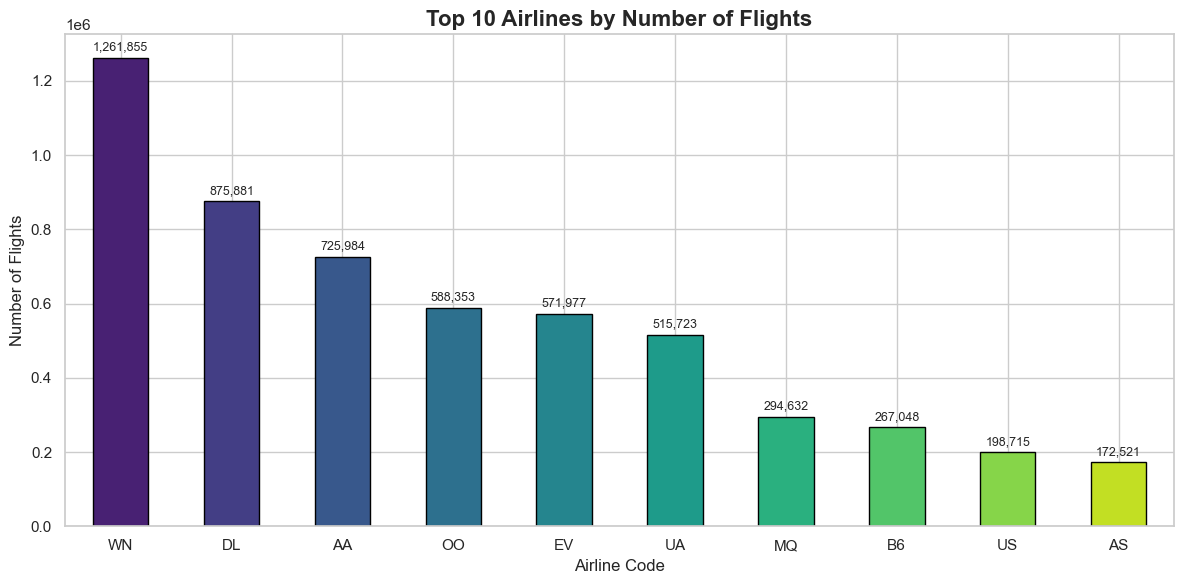

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))
airline_counts = flights['AIRLINE'].value_counts().head(10)
colors = sns.color_palette('viridis', len(airline_counts))
airline_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Top 10 Airlines by Number of Flights', fontsize=16, fontweight='bold')
ax.set_xlabel('Airline Code', fontsize=12)
ax.set_ylabel('Number of Flights', fontsize=12)
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(airline_counts):
    ax.text(i, v + 20000, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Plot 2: Monthly Flight Distribution (Line Chart)

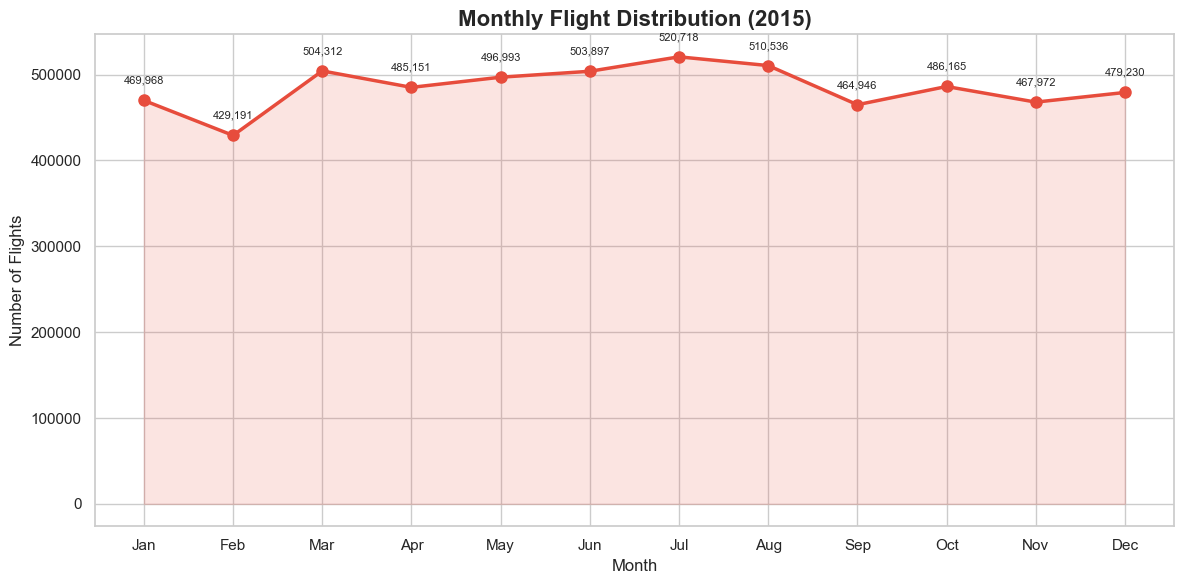

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
monthly = flights.groupby('MONTH').size()
ax.plot(monthly.index, monthly.values, marker='o', linewidth=2.5, color='#e74c3c', markersize=8)
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#e74c3c')
ax.set_title('Monthly Flight Distribution (2015)', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Flights', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
for x, y in zip(monthly.index, monthly.values):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### Plot 3: Flights by Day of Week (Bar Chart)

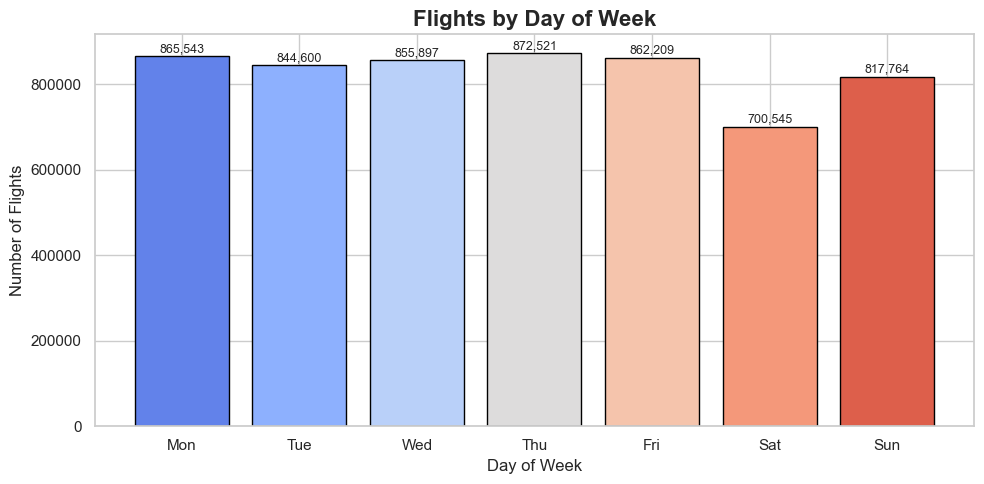

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
day_counts = flights['DAY_OF_WEEK'].value_counts().sort_index()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = sns.color_palette('coolwarm', 7)
bars = ax.bar(day_labels, day_counts.values, color=colors, edgecolor='black')
ax.set_title('Flights by Day of Week', fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Number of Flights', fontsize=12)
for bar, v in zip(bars, day_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 10000, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Plot 4: Hourly Flight Distribution (Histogram)

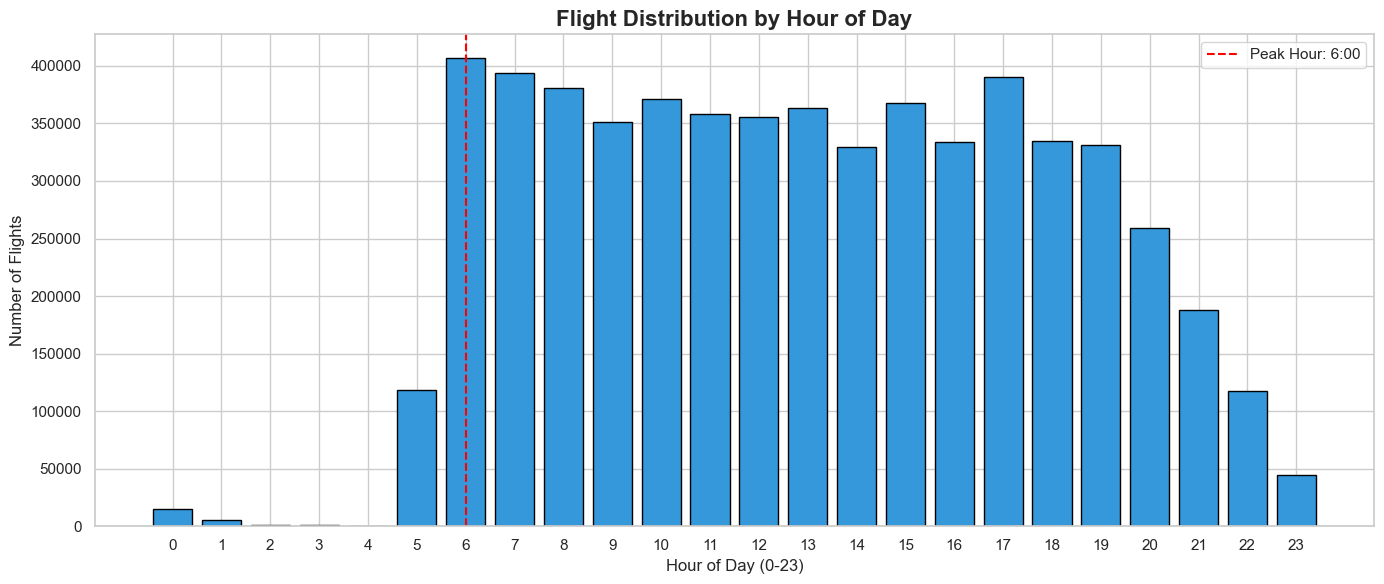

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
hour_counts = flights['HOUR'].value_counts().sort_index()
ax.bar(hour_counts.index, hour_counts.values, color='#3498db', edgecolor='black', width=0.8)
ax.set_title('Flight Distribution by Hour of Day', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day (0-23)', fontsize=12)
ax.set_ylabel('Number of Flights', fontsize=12)
ax.set_xticks(range(0, 24))
ax.axvline(x=hour_counts.idxmax(), color='red', linestyle='--', label=f'Peak Hour: {hour_counts.idxmax()}:00')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 9. Bivariate Analysis

### Plot 5: Average Departure Delay by Airline (Horizontal Bar)

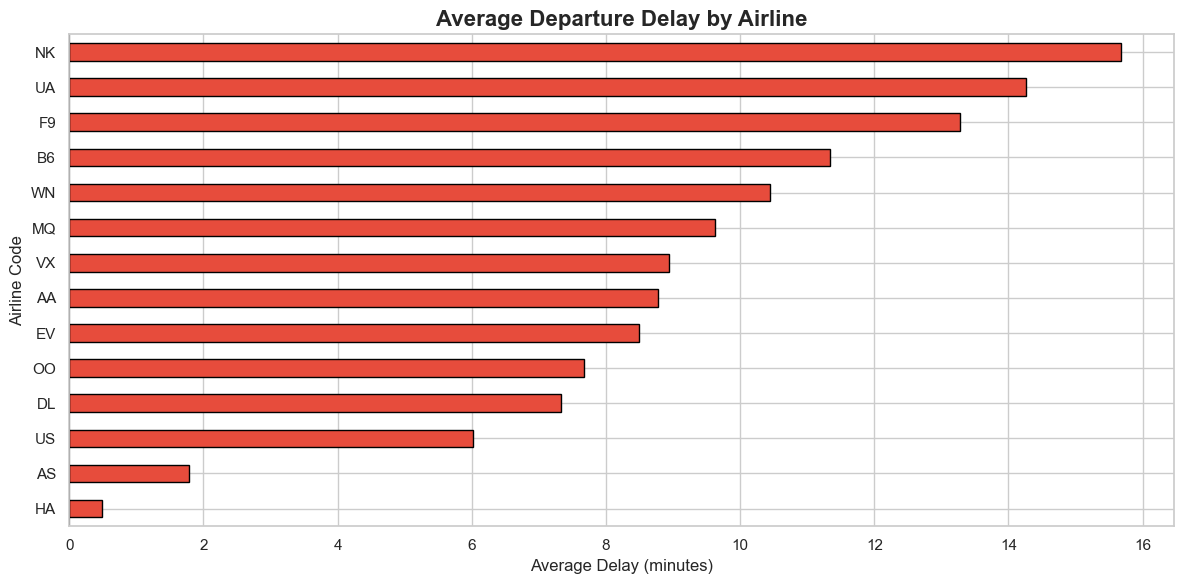

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))
avg_delay = flights.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values(ascending=True)
colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in avg_delay.values]
avg_delay.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Average Departure Delay by Airline', fontsize=16, fontweight='bold')
ax.set_xlabel('Average Delay (minutes)', fontsize=12)
ax.set_ylabel('Airline Code', fontsize=12)
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Plot 6: Average Departure Delay by Hour of Day (Line Chart)

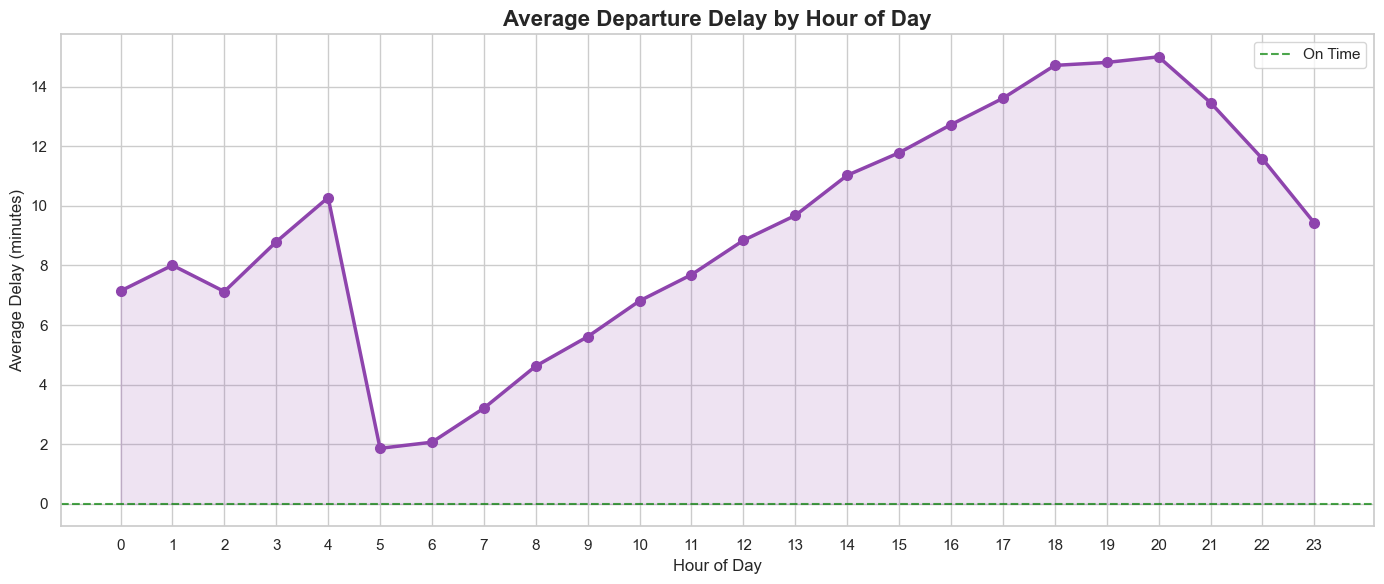

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))
hourly_delay = flights.groupby('HOUR')['DEPARTURE_DELAY'].mean()
ax.plot(hourly_delay.index, hourly_delay.values, marker='o', linewidth=2.5, color='#8e44ad', markersize=7)
ax.fill_between(hourly_delay.index, hourly_delay.values, alpha=0.15, color='#8e44ad')
ax.set_title('Average Departure Delay by Hour of Day', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Average Delay (minutes)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.axhline(y=0, color='green', linestyle='--', alpha=0.7, label='On Time')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Plot 7: Top 10 Busiest Routes (Bar Chart)

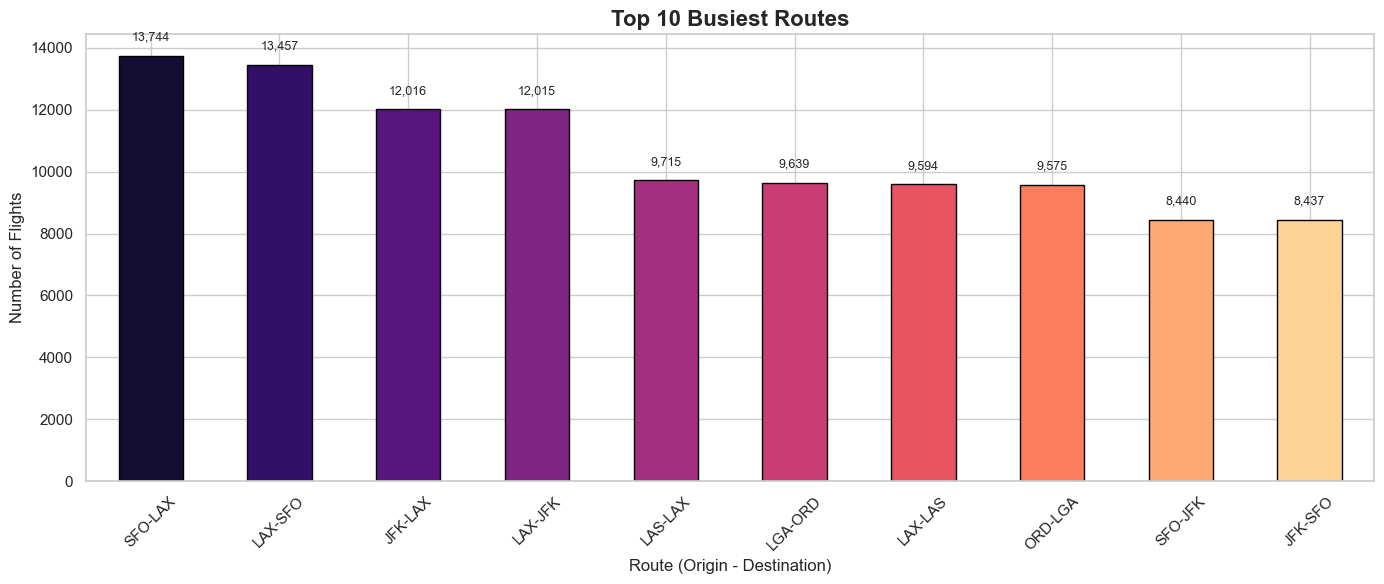

In [21]:
fig, ax = plt.subplots(figsize=(14, 6))
top_routes = flights['ROUTE'].value_counts().head(10)
colors = sns.color_palette('magma', len(top_routes))
top_routes.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
ax.set_title('Top 10 Busiest Routes', fontsize=16, fontweight='bold')
ax.set_xlabel('Route (Origin - Destination)', fontsize=12)
ax.set_ylabel('Number of Flights', fontsize=12)
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(top_routes):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### Plot 8: Departure Delay Distribution by Top Airlines (Box Plot)

C:\Users\hp\AppData\Local\Temp\ipykernel_20492\2446396123.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AIRLINE', y='DEPARTURE_DELAY', data=delay_data_filtered, palette='Set2', ax=ax,


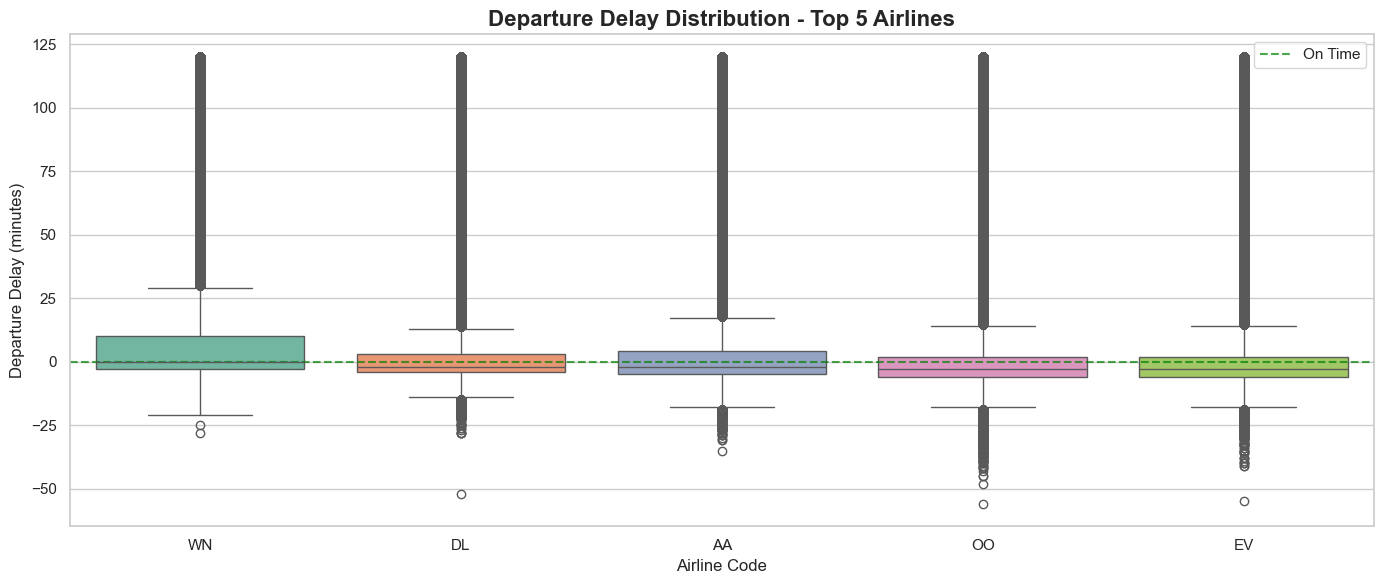

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
top_5_airlines = flights['AIRLINE'].value_counts().head(5).index
delay_data = flights[flights['AIRLINE'].isin(top_5_airlines)]
# Limit to -60 to 120 min for readability
delay_data_filtered = delay_data[(delay_data['DEPARTURE_DELAY'] >= -60) & (delay_data['DEPARTURE_DELAY'] <= 120)]
sns.boxplot(x='AIRLINE', y='DEPARTURE_DELAY', data=delay_data_filtered, palette='Set2', ax=ax,
            order=top_5_airlines)
ax.set_title('Departure Delay Distribution - Top 5 Airlines', fontsize=16, fontweight='bold')
ax.set_xlabel('Airline Code', fontsize=12)
ax.set_ylabel('Departure Delay (minutes)', fontsize=12)
ax.axhline(y=0, color='green', linestyle='--', alpha=0.7, label='On Time')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 10. Delay Cause Analysis

Analyzing the breakdown of delays by their causes:
* **Airline Delay** – Maintenance, crew, aircraft issues
* **Weather Delay** – Storms, fog, snow
* **NAS Delay** – Air traffic control, airport operations
* **Security Delay** – Security breaches, screening
* **Late Aircraft Delay** – Previous flight arrived late

### Plot 9: Total Delay Minutes by Cause (Pie Chart)

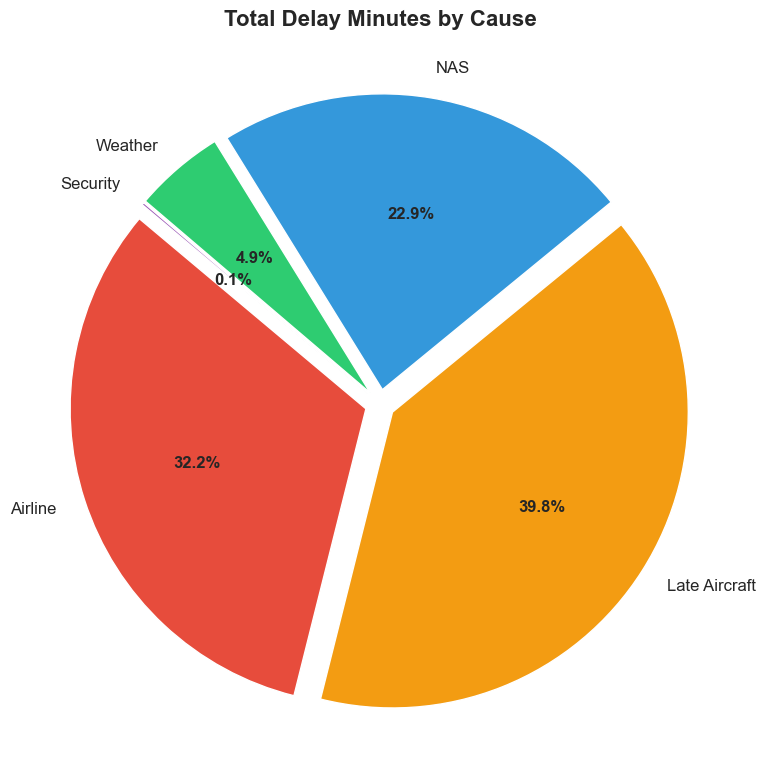

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
delay_causes = {
    'Airline': flights['AIRLINE_DELAY'].sum(),
    'Late Aircraft': flights['LATE_AIRCRAFT_DELAY'].sum(),
    'NAS': flights['AIR_SYSTEM_DELAY'].sum(),
    'Weather': flights['WEATHER_DELAY'].sum(),
    'Security': flights['SECURITY_DELAY'].sum()
}
labels = list(delay_causes.keys())
values = list(delay_causes.values())
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
explode = (0.05, 0.05, 0.05, 0.05, 0.05)
wedges, texts, autotexts = ax.pie(values, labels=labels, autopct='%1.1f%%', colors=colors,
                                   explode=explode, startangle=140, textprops={'fontsize': 12})
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Total Delay Minutes by Cause', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 10: Average Delay Cause Breakdown by Airline (Stacked Bar)

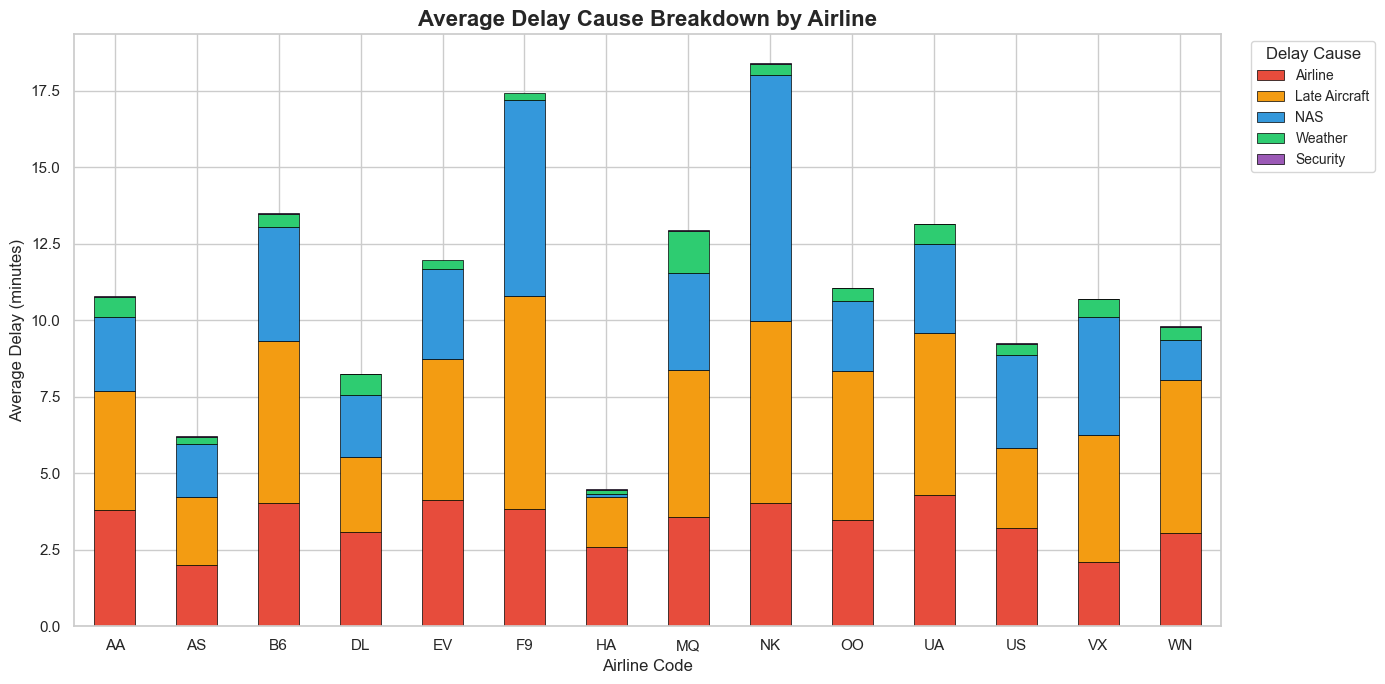

In [24]:
fig, ax = plt.subplots(figsize=(14, 7))
delay_cause_cols = ['AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'AIR_SYSTEM_DELAY',
                    'WEATHER_DELAY', 'SECURITY_DELAY']
cause_labels = ['Airline', 'Late Aircraft', 'NAS', 'Weather', 'Security']
airline_delay_causes = flights.groupby('AIRLINE')[delay_cause_cols].mean()
airline_delay_causes.columns = cause_labels
airline_delay_causes.plot(kind='bar', stacked=True, ax=ax,
                          color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6'],
                          edgecolor='black', linewidth=0.5)
ax.set_title('Average Delay Cause Breakdown by Airline', fontsize=16, fontweight='bold')
ax.set_xlabel('Airline Code', fontsize=12)
ax.set_ylabel('Average Delay (minutes)', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Delay Cause', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## 11. Cancellation Analysis

### Plot 11: Cancellations by Reason (Bar Chart)

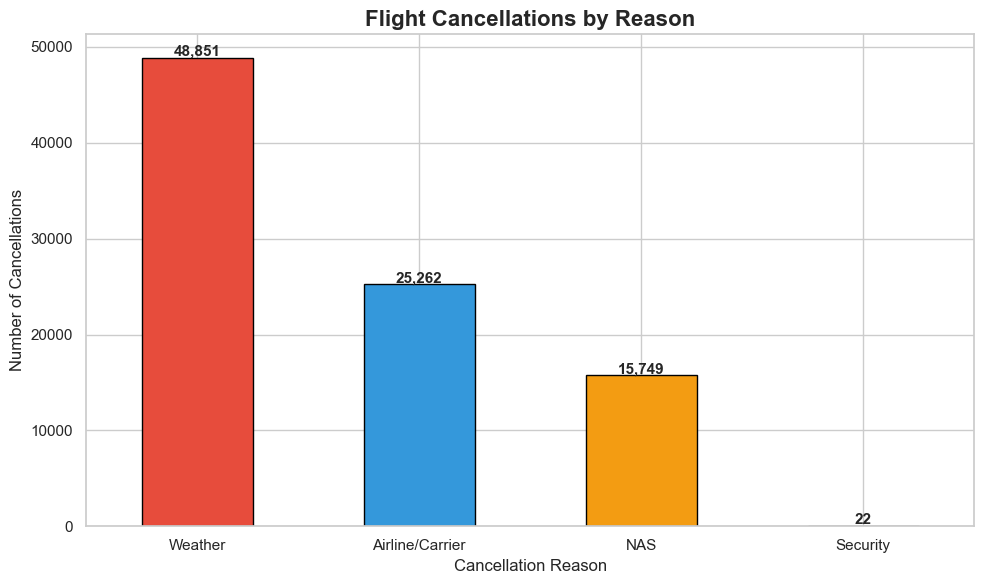

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
cancelled = flights[flights['CANCELLED'] == 1]
reason_counts = cancelled['CANCELLATION_REASON'].value_counts()
reason_labels = {'A': 'Airline/Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security'}
reason_counts.index = [reason_labels.get(r, r) for r in reason_counts.index]
colors = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']
reason_counts.plot(kind='bar', ax=ax, color=colors[:len(reason_counts)], edgecolor='black')
ax.set_title('Flight Cancellations by Reason', fontsize=16, fontweight='bold')
ax.set_xlabel('Cancellation Reason', fontsize=12)
ax.set_ylabel('Number of Cancellations', fontsize=12)
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(reason_counts):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Plot 12: Monthly Cancellation Trend (Line Chart)

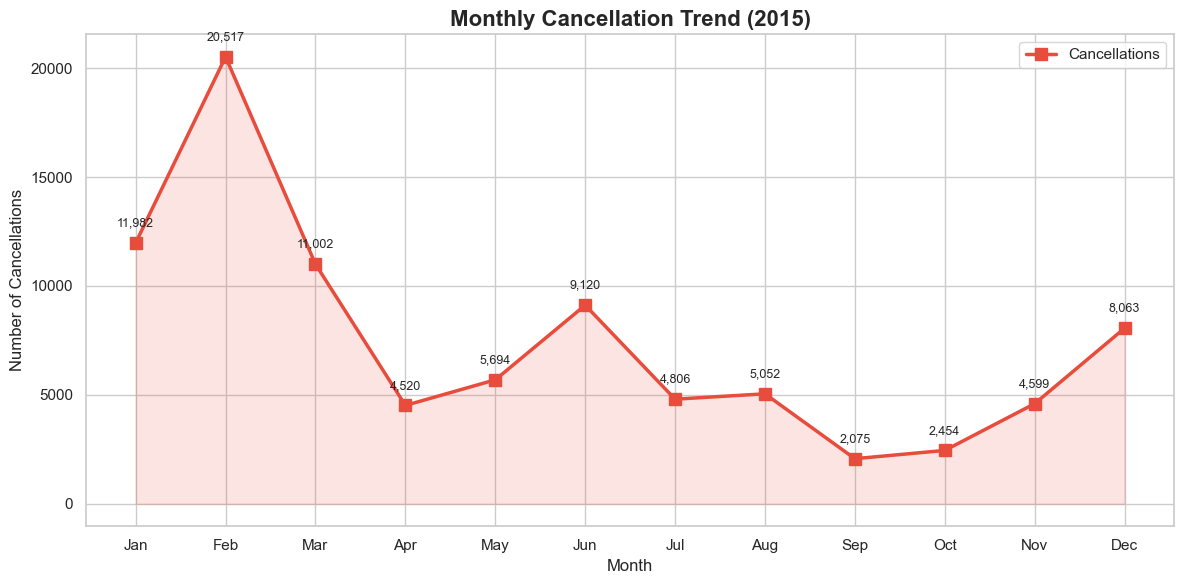

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
monthly_cancel = flights.groupby('MONTH')['CANCELLED'].sum()
ax.plot(monthly_cancel.index, monthly_cancel.values, marker='s', linewidth=2.5, color='#e74c3c',
        markersize=8, label='Cancellations')
ax.fill_between(monthly_cancel.index, monthly_cancel.values, alpha=0.15, color='#e74c3c')
ax.set_title('Monthly Cancellation Trend (2015)', fontsize=16, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Cancellations', fontsize=12)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
for x, y in zip(monthly_cancel.index, monthly_cancel.values):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## Milestone 2 Summary

### Visualizations Created (12 Total):

**Univariate Analysis (Plots 1-4):**
1. Top 10 Airlines by Number of Flights (Bar Chart)
2. Monthly Flight Distribution (Line Chart)
3. Flights by Day of Week (Bar Chart)
4. Hourly Flight Distribution (Histogram)

**Bivariate Analysis (Plots 5-8):**
5. Average Departure Delay by Airline (Horizontal Bar)
6. Average Departure Delay by Hour of Day (Line Chart)
7. Top 10 Busiest Routes (Bar Chart)
8. Departure Delay Distribution by Airlines (Box Plot)

**Delay Cause Analysis (Plots 9-10):**
9. Total Delay Minutes by Cause (Pie Chart)
10. Average Delay Cause Breakdown by Airline (Stacked Bar)

**Cancellation Analysis (Plots 11-12):**
11. Cancellations by Reason (Bar Chart)
12. Monthly Cancellation Trend (Line Chart)

---

**Key Insights:**
* Late Aircraft and Airline delays are the largest contributors to total delay minutes
* Delays increase significantly in evening hours (after 3 PM)
* Weather-related cancellations are the most common reason for flight cancellations
* Saturday has the lowest flight volume among all days of the week

In [27]:
flights.to_csv("../data/cleaned_flights.csv", index=False)